In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.cifar10.load_data()

Labels: [9]


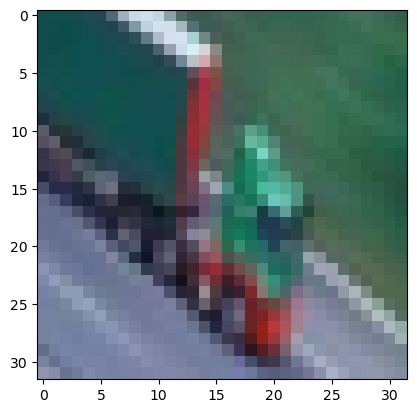

In [5]:
plt.imshow(X_train[50])
print("Labels:", Y_train[50])

In [4]:
#normalize the input
X_train = X_train/255.0
X_test = X_test/255.0

In [7]:
X_train.shape

(50000, 32, 32, 3)

In [9]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [12]:
print("Class names:", class_names)
print("Example label:", Y_train[0], "->", class_names[Y_train[0][0]])

Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Example label: [6] -> frog


In [5]:
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Input, GlobalAveragePooling2D, ReLU, BatchNormalization, MaxPooling2D

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

In [26]:
def base_model():
    input_x= tf.keras.layers.Input(shape= (32,32,3))
    x= data_augmentation(input_x)
    x= Conv2D(32, (3,3), strides= 1, padding= "same", use_bias= False)(x)
    x= BatchNormalization()(x)
    x = ReLU()(x)
    x= MaxPooling2D((2, 2), strides=(2, 2))(x)
    
    x= Conv2D(64, (3,3), strides= 1, padding= "same", use_bias= False)(x)
    x= BatchNormalization()(x)
    x = ReLU()(x)
    x= MaxPooling2D((2, 2), strides=(2, 2))(x)
    
    x= Conv2D(128, (3,3), strides= 1, padding= "same", use_bias= False)(x)
    x= BatchNormalization()(x)
    x = ReLU()(x)
    x= GlobalAveragePooling2D()(x)
    x= Dense(128, activation= "relu")(x)
    x= Dropout(0.2)(x)

    x= Dense(10, activation= "softmax")(x)
    model= tf.keras.Model(inputs= input_x, outputs= x)
    return model
    

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=5,               
    restore_best_weights=True )

checkpoint = ModelCheckpoint(
    filepath='models/wider_model.keras', 
    monitor='val_loss',      
    save_best_only=True,      
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-5,
    verbose=1
)

In [28]:
base_model= base_model()
base_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 32, 32, 32)          │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_9 (ReLU)                       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 16, 16, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_10 (ReLU)                      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 8, 8, 128)           │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_11 (ReLU)                      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,722 (436.41 KB)

 Trainable params: 111,274 (434.66 KB)

 Non-trainable params: 448 (1.75 KB)

In [47]:
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [48]:
history = base_model.fit(
    X_train, Y_train,
    epochs=30,
    batch_size = 64,
    validation_split= 0.2,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6077 - loss: 1.1014
Epoch 1: val_loss improved from None to 1.36476, saving model to base_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - accuracy: 0.6094 - loss: 1.0980 - val_accuracy: 0.5462 - val_loss: 1.3648 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6272 - loss: 1.0523
Epoch 2: val_loss did not improve from 1.36476
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.6263 - loss: 1.0507 - val_accuracy: 0.5257 - val_loss: 1.4122 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6323 - loss: 1.0320
Epoch 3: val_loss improved from 1.36476 to 1.11780, saving model to base_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.6364 - loss: 1.0226 - val_accuracy: 0.6054 - val_loss: 1.1178 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6486 - loss: 0.9930
Epoch 4: 

In [49]:
test_loss, test_acc = base_model.evaluate(X_test, Y_test, verbose=2)
print(f'\nTest accuracy: {test_acc}')

313/313 - 2s - 7ms/step - accuracy: 0.7625 - loss: 0.6830

Test accuracy: 0.762499988079071


## Increasing architecture depth to counter high bias/underfitting

In [9]:
def second_model():
    input_x= tf.keras.layers.Input(shape= (32,32,3))
    x= data_augmentation(input_x)
    x= Conv2D(32, (3,3), strides= 1, padding= "same", use_bias= False)(x)
    x= BatchNormalization()(x)
    x = ReLU()(x)
    x= Conv2D(32, (3,3), strides= 1, padding= "same", use_bias= False)(x)
    x= BatchNormalization()(x)
    x = ReLU()(x)
    x= MaxPooling2D((2, 2), strides=(2, 2))(x)
    
    x= Conv2D(64, (3,3), strides= 1, padding= "same", use_bias= False)(x)
    x= BatchNormalization()(x)
    x = ReLU()(x)
    x= Conv2D(64, (3,3), strides= 1, padding= "same", use_bias= False)(x)
    x= BatchNormalization()(x)
    x = ReLU()(x)
    x= MaxPooling2D((2, 2), strides=(2, 2))(x)
    
    x= Conv2D(128, (3,3), strides= 1, padding= "same", use_bias= False)(x)
    x= BatchNormalization()(x)
    x = ReLU()(x)
    x= Conv2D(128, (3,3), strides= 1, padding= "same", use_bias= False)(x)
    x= BatchNormalization()(x)
    x = ReLU()(x)
    
    x= GlobalAveragePooling2D()(x)
    x= Dense(128, activation= "relu")(x)
    x= Dropout(0.1)(x) # decreasing dropout rate to increase fitting

    x= Dense(10, activation= "softmax")(x)
    model= tf.keras.Model(inputs= input_x, outputs= x)
    return model
    

In [10]:
second_model= second_model()
second_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_3 (ReLU)                       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_4 (ReLU)                       │ (None, 8, 8, 128)           │              

 Total params: 306,154 (1.17 MB)

 Trainable params: 305,258 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
second_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [13]:
history = second_model.fit(
    X_train, Y_train,
    epochs=30,
    batch_size = 64,
    validation_split= 0.2,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.3947 - loss: 1.6429
Epoch 1: val_loss improved from None to 2.05359, saving model to models/wider_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 163ms/step - accuracy: 0.4645 - loss: 1.4598 - val_accuracy: 0.3628 - val_loss: 2.0536 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.5721 - loss: 1.1879
Epoch 2: val_loss improved from 2.05359 to 1.06071, saving model to models/wider_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 169ms/step - accuracy: 0.5929 - loss: 1.1354 - val_accuracy: 0.6131 - val_loss: 1.0607 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6424 - loss: 1.0127
Epoch 3: val_loss did not improve from 1.06071
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 169ms/step - accuracy: 0.6548 - loss: 0.9814 - val_accuracy: 0.4844 - val_loss: 1.8038 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.687

In [15]:
test_loss, test_acc = second_model.evaluate(X_test, Y_test, verbose=2)
print(f'\nTest accuracy: {test_acc}')

313/313 - 4s - 14ms/step - accuracy: 0.8442 - loss: 0.4662

Test accuracy: 0.8442000150680542
